# Sistema híbrido de recomendación de anime

**Trabajo Práctico 2 — Análisis Predictivo Avanzado**

Este notebook construye, optimiza y evalúa un sistema de recomendación top-k para una plataforma hipotética de streaming de anime.

El objetivo operativo consiste en seleccionar los diez títulos no vistos que deberían mostrarse primero a cada usuario. La implementación compara baselines de popularidad y contenido con modelos colaborativos e híbridos entrenados mediante objetivos logísticos, BPR y muestreo de negativos difíciles inspirado en WARP.

## 1. Diseño del experimento

La unidad de análisis es una interacción positiva entre un usuario y un anime. Se considera positiva una calificación explícita de al menos 8 puntos.

El conjunto de datos no contiene marcas temporales confiables. Por este motivo, la separación se realiza aleatoriamente dentro de cada usuario, utilizando semillas determinísticas. Cada usuario conserva observaciones en entrenamiento, validación y prueba.

La validación se utilizará para comparar arquitecturas, pérdidas e hiperparámetros. El conjunto de prueba permanecerá reservado hasta que todas las decisiones de modelado hayan sido fijadas.

In [1]:
%matplotlib inline

from pathlib import Path
import json
import platform
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from anime_recommender import (
    load_experiment_config,
    prepare_data,
)

ROOT = Path.cwd().resolve()

if ROOT.name == "notebooks":
    ROOT = ROOT.parent

CONFIG_PATH = ROOT / "config" / "experiment.json"
ANIME_PATH = ROOT / "data" / "anime.csv"
RATINGS_PATH = ROOT / "data" / "rating.parquet"

config = load_experiment_config(CONFIG_PATH)

print("Project root:", ROOT)
print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())
print("Modeling framework:", config["framework"])
print("Device:", config["device"])

Project root: C:\TP2\AnimeLightFM
Python: 3.11.15
Platform: Windows-10-10.0.26200-SP0
Modeling framework: pytorch
Device: cpu


In [2]:
display(
    pd.DataFrame(
        {
            "Parameter": list(config.keys()),
            "Value": [
                json.dumps(value)
                if isinstance(value, (list, dict))
                else value
                for value in config.values()
            ],
        }
    )
)

,Parameter,Value
0,experiment_name,anime_hybrid_pytorch
1,framework,pytorch
2,seed,42
3,positive_rating_threshold,8
4,target_user_count,1500
5,minimum_user_positives_before_sampling,20
6,maximum_user_positives_before_sampling,300
7,minimum_user_positives_after_filtering,15
8,minimum_item_users,5
9,validation_fraction,0.1


## 2. Carga, validación y definición de interacciones positivas

El catálogo y las calificaciones se validan antes de cualquier modelado. Los identificadores se convierten a enteros, los títulos se normalizan y las referencias a anime inexistentes se eliminan.

Las calificaciones iguales a `-1` representan consumo sin una evaluación explícita. Se excluyen del conjunto positivo principal. Una interacción positiva requiere una calificación mayor o igual a 8.

In [3]:
prepared = prepare_data(
    anime_path=ANIME_PATH,
    ratings_path=RATINGS_PATH,
    config=config,
)

summary_table = pd.DataFrame(
    {
        "Measure": list(prepared.summary.keys()),
        "Value": list(prepared.summary.values()),
    }
)

display(summary_table)

,Measure,Value
0,anime_sha256,26c27b66120342544f19c9acb575e3dcbf37d46d1898ae...
1,ratings_sha256,5f70fd74327974c0c2c35159efba1a0a5634de139e09ff...
2,raw_catalog_rows,12294
3,raw_rating_rows,7813737
4,rows_with_missing_required_values,0
5,rows_participating_in_duplicate_pairs,14
6,duplicate_pair_records_removed,7
7,deduplicated_rating_rows,7813730
8,orphan_rating_rows_removed,10
9,positive_interactions_before_sampling,3855825


## 3. Cohorte determinística

Los usuarios candidatos deben tener suficiente historial positivo para sostener una evaluación individual. Los identificadores elegibles se ordenan antes del muestreo y se utiliza una semilla fija.

Luego se aplican iterativamente dos restricciones:

- Cada usuario debe conservar como mínimo la cantidad configurada de interacciones positivas.
- Cada anime debe haber sido valorado positivamente por al menos la cantidad configurada de usuarios.

El proceso se repite hasta que ambas condiciones se cumplen simultáneamente.

In [4]:
user_positive_counts = (
    prepared.interactions
    .groupby("user_id")
    .size()
)

item_positive_counts = (
    prepared.interactions
    .groupby("anime_id")
    .size()
)

count_diagnostics = pd.DataFrame(
    {
        "Statistic": [
            "Users",
            "Items",
            "Positive interactions",
            "Minimum positives per user",
            "Median positives per user",
            "Maximum positives per user",
            "Minimum users per item",
            "Median users per item",
            "Maximum users per item",
        ],
        "Value": [
            prepared.interactions["user_id"].nunique(),
            prepared.interactions["anime_id"].nunique(),
            len(prepared.interactions),
            user_positive_counts.min(),
            user_positive_counts.median(),
            user_positive_counts.max(),
            item_positive_counts.min(),
            item_positive_counts.median(),
            item_positive_counts.max(),
        ],
    }
)

display(count_diagnostics)

,Statistic,Value
0,Users,1498.0
1,Items,2438.0
2,Positive interactions,110025.0
3,Minimum positives per user,17.0
4,Median positives per user,54.0
5,Maximum positives per user,292.0
6,Minimum users per item,5.0
7,Median users per item,19.0
8,Maximum users per item,805.0


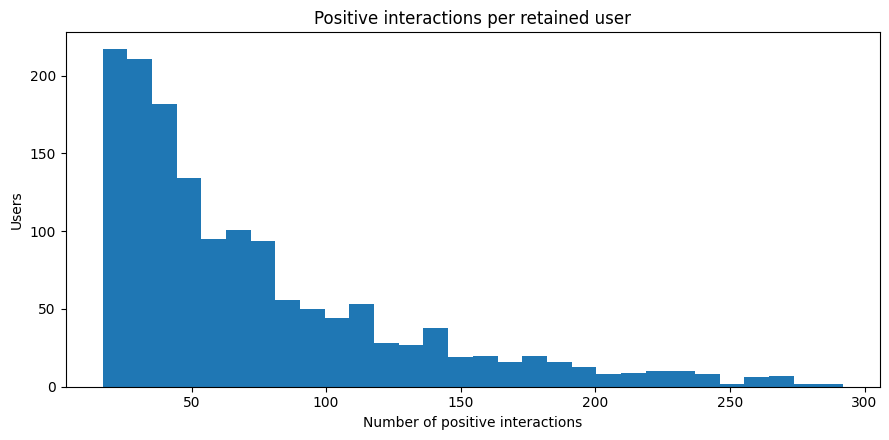

In [5]:
fig, ax = plt.subplots(figsize=(9, 4.5))

ax.hist(
    user_positive_counts,
    bins=30,
)

ax.set_title(
    "Positive interactions per retained user"
)
ax.set_xlabel(
    "Number of positive interactions"
)
ax.set_ylabel(
    "Users"
)

plt.tight_layout()
plt.show()

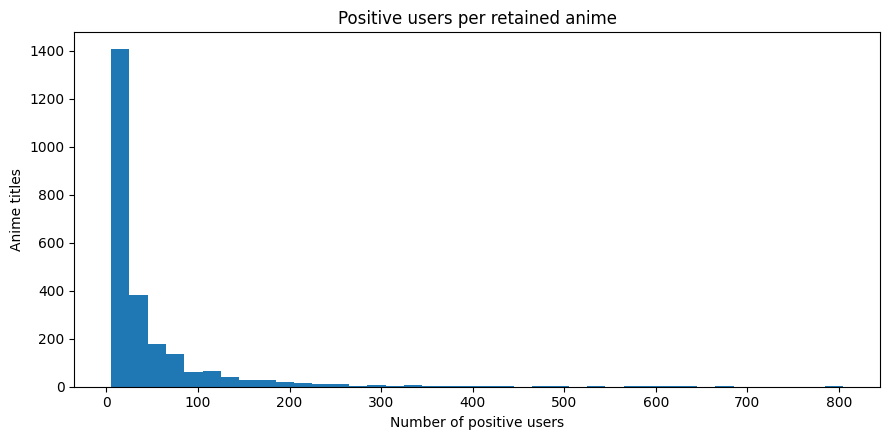

In [6]:
fig, ax = plt.subplots(figsize=(9, 4.5))

ax.hist(
    item_positive_counts,
    bins=40,
)

ax.set_title(
    "Positive users per retained anime"
)
ax.set_xlabel(
    "Number of positive users"
)
ax.set_ylabel(
    "Anime titles"
)

plt.tight_layout()
plt.show()

## 4. Train, validation and test split

Every user has at least one validation interaction and one test interaction. The remainder is assigned to training.

A deterministic repair step guarantees that every retained anime appears at least once in training. When necessary, it exchanges a held-out interaction with a training interaction from the same user without leaving the replacement anime unsupported.

This avoids evaluating collaborative models on item identifiers that were never observed during training.

In [7]:
split_counts = (
    prepared.split_interactions
    .groupby("split")
    .agg(
        interactions=("anime_id", "size"),
        users=("user_id", "nunique"),
        items=("anime_id", "nunique"),
    )
    .reindex(
        [
            "train",
            "validation",
            "test",
        ]
    )
)

display(split_counts)

,interactions,users,items
split,,,
train,89313,1498,2438
validation,10356,1498,1878
test,10356,1498,1875


In [8]:
per_user_split_counts = (
    prepared.split_interactions
    .groupby(
        [
            "user_id",
            "split",
        ]
    )
    .size()
    .unstack(fill_value=0)
)

display(
    per_user_split_counts.describe().T
)

,count,mean,std,min,25%,50%,75%,max
split,,,,,,,,
test,1498.0,6.913218,5.475074,1.0,3.0,5.0,9.0,29.0
train,1498.0,59.621495,43.864981,15.0,27.0,44.0,78.0,234.0
validation,1498.0,6.913218,5.475074,1.0,3.0,5.0,9.0,29.0


In [9]:
assert (
    prepared.train_matrix.multiply(
        prepared.validation_matrix
    ).nnz
    == 0
)

assert (
    prepared.train_matrix.multiply(
        prepared.test_matrix
    ).nnz
    == 0
)

assert (
    prepared.validation_matrix.multiply(
        prepared.test_matrix
    ).nnz
    == 0
)

assert prepared.summary[
    "items_without_training_support"
] == 0

assert (
    prepared.train_matrix.nnz
    + prepared.validation_matrix.nnz
    + prepared.test_matrix.nnz
    == prepared.all_positive_matrix.nnz
)

print(
    "Split integrity checks passed."
)
print(
    "Cohort hash:",
    prepared.summary[
        "cohort_split_sha256"
    ],
)

Split integrity checks passed.
Cohort hash: 02a81cb1bbdf5e955469426444a2500443a4412217197821e4f66d3c71dec1bf


## 5. Phase 2 conclusion

The final cohort, mappings, and split assignments are deterministic and free of overlap. Every retained user is represented in all three subsets, and every retained item has training support.

The following sections will construct metadata features, evaluation functions, baselines, and the collaborative and hybrid recommendation models.

## 6. Representación de metadatos

Cada anime se representa mediante variables binarias de género y tipo. Los nombres de las características y los índices de los ítems se ordenan de forma determinística.

Las filas se normalizan con norma L2. Esta normalización permite interpretar el producto punto entre dos vectores como una similitud coseno y evita favorecer automáticamente a los títulos asociados con más géneros.

In [10]:
from anime_recommender import (
    build_item_features,
)

item_features = build_item_features(
    prepared.catalog
)

display(
    pd.DataFrame(
        {
            "Measure": list(
                item_features.summary.keys()
            ),
            "Value": list(
                item_features.summary.values()
            ),
        }
    )
)

,Measure,Value
0,items,2438.0
1,features,49.0
2,genre_features,43.0
3,type_features,6.0
4,nonzero_values,12768.0
5,minimum_features_per_item,2.0
6,median_features_per_item,5.0
7,maximum_features_per_item,14.0
8,minimum_feature_frequency,2.0
9,maximum_feature_frequency,1359.0


In [11]:
feature_frequencies = np.asarray(
    item_features.matrix.sum(axis=0)
).ravel()

feature_frequency_table = (
    pd.DataFrame(
        {
            "feature": (
                item_features.feature_names
            ),
            "anime_count": (
                feature_frequencies.astype(
                    int
                )
            ),
        }
    )
    .sort_values(
        [
            "anime_count",
            "feature",
        ],
        ascending=[
            False,
            True,
        ],
    )
    .reset_index(drop=True)
)

display(
    feature_frequency_table.head(20)
)

,feature,anime_count
0,type:tv,1359
1,genre:comedy,1238
2,genre:action,912
3,genre:romance,696
4,genre:drama,652
5,genre:shounen,600
6,genre:fantasy,592
7,genre:sci-fi,541
8,genre:adventure,522
9,genre:school,510


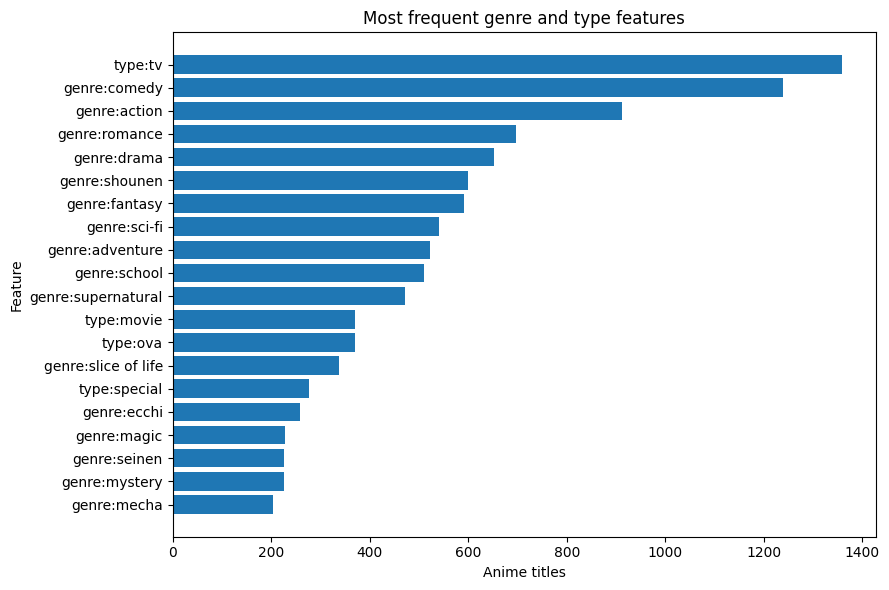

In [12]:
top_features = (
    feature_frequency_table
    .head(20)
    .sort_values(
        "anime_count"
    )
)

fig, ax = plt.subplots(
    figsize=(9, 6)
)

ax.barh(
    top_features["feature"],
    top_features["anime_count"],
)

ax.set_title(
    "Most frequent genre and type features"
)
ax.set_xlabel(
    "Anime titles"
)
ax.set_ylabel(
    "Feature"
)

plt.tight_layout()
plt.show()

## 7. Protocolo de evaluación

Todos los modelos generan un puntaje para cada combinación usuario-anime. Antes del ranking se excluyen las interacciones positivas observadas en entrenamiento.

La métrica principal es Precision@10. También se reportan Recall@10, NDCG@10, Hit Rate@10, AUC con negativos muestreados, cobertura del catálogo y diversidad interna.

Los empates de puntaje se resuelven por índice de ítem. Esto evita que el orden de resultados dependa de implementaciones internas o del sistema operativo.

## 8. Baselines

Se utilizan dos referencias mínimas.

**Popularidad**

Ordena los títulos según la cantidad de interacciones positivas observadas en entrenamiento. Permite determinar si los modelos personalizados agregan valor frente a una estrategia global.

**Contenido**

Construye un perfil por usuario sumando los vectores normalizados de sus títulos positivos de entrenamiento. Luego ordena el catálogo por similitud coseno con dicho perfil.

In [13]:
from anime_recommender import (
    evaluate_baselines,
    recommendation_examples,
)

(
    baseline_validation_results,
    baseline_recommendations,
) = evaluate_baselines(
    prepared=prepared,
    item_features=item_features,
    config=config,
)

display(
    baseline_validation_results
)

,model,precision_at_10,recall_at_10,ndcg_at_10,hit_rate_at_10,catalog_coverage_at_10,intra_list_diversity_at_10,sampled_auc
0,popularity,0.052470,0.093870,0.087683,0.393858,0.015176,0.627193,0.829304
1,content,0.014286,0.024942,0.022778,0.133511,0.291632,0.228756,0.709875


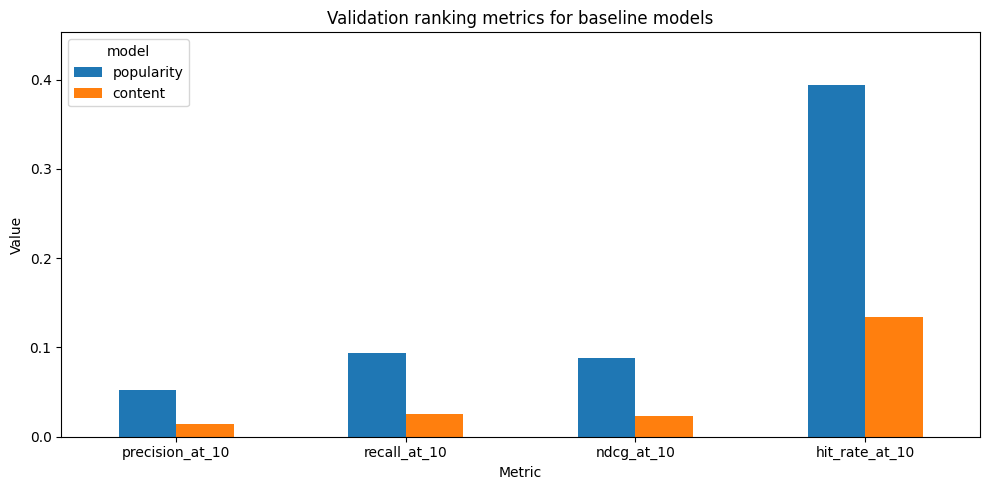

In [14]:
metric_columns = [
    column
    for column in (
        baseline_validation_results.columns
    )
    if column != "model"
]

baseline_plot_data = (
    baseline_validation_results
    .set_index("model")[
        [
            "precision_at_10",
            "recall_at_10",
            "ndcg_at_10",
            "hit_rate_at_10",
        ]
    ]
    .T
)

ax = baseline_plot_data.plot(
    kind="bar",
    figsize=(10, 5),
)

ax.set_title(
    "Validation ranking metrics for baseline models"
)
ax.set_xlabel(
    "Metric"
)
ax.set_ylabel(
    "Value"
)
ax.set_ylim(
    0,
    max(
        0.05,
        baseline_plot_data.to_numpy().max()
        * 1.15,
    ),
)
ax.tick_params(
    axis="x",
    rotation=0,
)

plt.tight_layout()
plt.show()

In [15]:
example_user_indices = [
    0,
    len(prepared.user_ids) // 2,
    len(prepared.user_ids) - 1,
]

baseline_examples = recommendation_examples(
    prepared=prepared,
    recommendations_by_model=(
        baseline_recommendations
    ),
    user_indices=example_user_indices,
)

display(
    baseline_examples[
        [
            "model",
            "user_id",
            "rank",
            "title",
            "genre",
            "type",
            "validation_hit",
        ]
    ]
)

,model,user_id,rank,title,genre,type,validation_hit
0,popularity,93,1,Death Note,"Mystery, Police, Psychological, Supernatural, ...",TV,False
1,popularity,93,2,Code Geass: Hangyaku no Lelouch,"Action, Mecha, Military, School, Sci-Fi, Super...",TV,False
2,popularity,93,3,Shingeki no Kyojin,"Action, Drama, Fantasy, Shounen, Super Power",TV,False
3,popularity,93,4,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,False
4,popularity,93,5,Code Geass: Hangyaku no Lelouch R2,"Action, Drama, Mecha, Military, Sci-Fi, Super ...",TV,False
5,popularity,93,6,Toradora!,"Comedy, Romance, School, Slice of Life",TV,False
6,popularity,93,7,Sen to Chihiro no Kamikakushi,"Adventure, Drama, Supernatural",Movie,False
7,popularity,93,8,Elfen Lied,"Action, Drama, Horror, Psychological, Romance,...",TV,False
8,popularity,93,9,Clannad,"Comedy, Drama, Romance, School, Slice of Life,...",TV,False
9,popularity,93,10,Fullmetal Alchemist,"Action, Adventure, Comedy, Drama, Fantasy, Mag...",TV,False


In [16]:
for model_name, recommendations in (
    baseline_recommendations.items()
):
    for user_index, item_indices in enumerate(
        recommendations
    ):
        assert (
            prepared.train_matrix[
                user_index,
                item_indices,
            ].nnz
            == 0
        )

assert (
    baseline_validation_results
    .drop(columns="model")
    .apply(
        lambda column: column.between(
            0,
            1,
        ).all()
    )
    .all()
)

print(
    "Baseline ranking and metric checks passed."
)

Baseline ranking and metric checks passed.


## 9. Conclusión de los baselines

La popularidad establece el rendimiento de una recomendación global sin personalización. El modelo de contenido incorpora preferencias individuales, aunque solo puede utilizar similitud explícita de género y tipo.

Los modelos colaborativos e híbridos posteriores deberán superar estas referencias en Precision@10 para justificar su mayor complejidad.

## 10. Modelos de factores latentes

Se implementa una arquitectura común con embeddings de usuario e ítem, sesgos y producto interno en un espacio latente.

La variante colaborativa representa cada anime mediante un embedding libre. La variante híbrida suma a ese embedding una proyección aprendida de sus géneros y tipo.

\[
s(u,i)=b+b_u+b_i+p_u^	op(q_i+lpha Wx_i)
\]

Esta estructura permite medir directamente el aporte de los metadatos manteniendo constante el resto de la arquitectura.

## 11. Objetivos de entrenamiento

Se comparan tres funciones objetivo.

**Logistic**

Clasifica interacciones observadas como positivas y negativos muestreados como negativos.

**BPR**

Maximiza la diferencia de puntaje entre un ítem positivo y un negativo muestreado.

\[
-\log \sigma(s(u,i^+)-s(u,i^-))
\]

**WARP-style hard negative**

Muestrea negativos secuencialmente hasta encontrar uno que viola un margen. El error recibe un peso armónico basado en el rango aproximado. Es una implementación propia inspirada en WARP, por lo que se evita presentarla como el algoritmo WARP exacto de LightFM.

## 12. Ejecución externa de PyTorch

En este equipo, PyTorch funciona correctamente en el proceso Conda activado, pero la inicialización de sus DLL falla dentro del subproceso del kernel Jupyter de Windows.

Por ese motivo, el entrenamiento se ejecuta mediante un script independiente dentro del mismo entorno reproducible. El notebook orquesta la ejecución y luego carga todos los resultados. La implementación, los parámetros y las salidas permanecen dentro del repositorio.

La variable `FORCE_RETRAIN_DEFAULT_MODELS` permite forzar una nueva ejecución. Si los resultados validados ya existen, se reutilizan para evitar repetir innecesariamente el entrenamiento durante cada apertura.

In [17]:
import os
import shutil
import subprocess

DEFAULT_RESULTS_DIR = (
    ROOT
    / "results"
    / "default_models"
)

REQUIRED_DEFAULT_RESULT_FILES = [
    DEFAULT_RESULTS_DIR
    / "validation_metrics.csv",
    DEFAULT_RESULTS_DIR
    / "training_history.csv",
    DEFAULT_RESULTS_DIR
    / "recommendation_examples.csv",
    DEFAULT_RESULTS_DIR
    / "recommendations.npz",
    DEFAULT_RESULTS_DIR
    / "run_summary.json",
]

FORCE_RETRAIN_DEFAULT_MODELS = False

results_are_complete = all(
    path.exists()
    for path in REQUIRED_DEFAULT_RESULT_FILES
)

if (
    FORCE_RETRAIN_DEFAULT_MODELS
    or not results_are_complete
):
    conda_candidates = [
        os.environ.get("CONDA_EXE"),
        shutil.which("conda"),
        str(
            Path.home()
            / "miniconda3"
            / "Scripts"
            / "conda.exe"
        ),
        str(
            Path.home()
            / "anaconda3"
            / "Scripts"
            / "conda.exe"
        ),
    ]

    conda_executable = next(
        (
            candidate
            for candidate in conda_candidates
            if candidate
            and Path(candidate).exists()
        ),
        None,
    )

    if conda_executable is None:
        raise FileNotFoundError(
            "A Conda executable could not be located."
        )

    command = [
        conda_executable,
        "run",
        "-n",
        "apa-tp2-final",
        "--no-capture-output",
        "python",
        "scripts/train_default_models.py",
        "--overwrite",
    ]

    print(
        "Running:",
        " ".join(command),
        flush=True,
    )

    process = subprocess.Popen(
        command,
        cwd=ROOT,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        encoding="utf-8",
        errors="replace",
        bufsize=1,
    )

    assert process.stdout is not None

    for output_line in process.stdout:
        print(
            output_line,
            end="",
            flush=True,
        )

    return_code = process.wait()

    if return_code != 0:
        raise RuntimeError(
            "Default-model training failed with "
            f"exit code {return_code}."
        )
else:
    print(
        "Using existing validated default-model results."
    )

Using existing validated default-model results.


In [18]:
default_validation_results = pd.read_csv(
    DEFAULT_RESULTS_DIR
    / "validation_metrics.csv"
)

default_training_history = pd.read_csv(
    DEFAULT_RESULTS_DIR
    / "training_history.csv"
)

default_examples = pd.read_csv(
    DEFAULT_RESULTS_DIR
    / "recommendation_examples.csv"
)

with (
    DEFAULT_RESULTS_DIR
    / "run_summary.json"
).open(
    "r",
    encoding="utf-8",
) as file:
    default_run_summary = json.load(
        file
    )

display(
    default_validation_results
)

,model,model_family,objective,uses_metadata,latent_dim,epochs,final_train_loss,parameter_count,precision_at_10,recall_at_10,ndcg_at_10,hit_rate_at_10,catalog_coverage_at_10,intra_list_diversity_at_10,sampled_auc
0,popularity,baseline,popularity,False,0,0,NaN,0,0.052470,0.093870,0.087683,0.393858,0.015176,0.627193,0.829304
1,content,baseline,content,True,0,0,NaN,0,0.014286,0.024942,0.022778,0.133511,0.291632,0.228756,0.709875
2,collaborative_logistic,pytorch,logistic,False,32,8,0.322932,129889,0.080975,0.145646,0.132884,0.546061,0.254307,0.602772,0.902361
3,collaborative_bpr,pytorch,bpr,False,32,8,0.186616,129889,0.078104,0.138057,0.127747,0.532710,0.239130,0.607079,0.898040
4,collaborative_warp_style,pytorch,warp_style_hard_negative,False,32,8,5.453697,129889,0.088451,0.157197,0.145286,0.578104,0.321165,0.610442,0.902638
5,hybrid_logistic,pytorch,logistic,True,32,8,0.317993,131457,0.085381,0.155899,0.142490,0.578104,0.284249,0.560137,0.912066
6,hybrid_bpr,pytorch,bpr,True,32,8,0.182673,131457,0.082043,0.145503,0.134561,0.549399,0.270714,0.556300,0.907231
7,hybrid_warp_style,pytorch,warp_style_hard_negative,True,32,8,5.877905,131457,0.095327,0.169775,0.159897,0.616155,0.334290,0.574260,0.914764


In [19]:
comparison_columns = [
    "model",
    "precision_at_10",
    "recall_at_10",
    "ndcg_at_10",
    "hit_rate_at_10",
    "sampled_auc",
    "catalog_coverage_at_10",
    "intra_list_diversity_at_10",
]

display(
    default_validation_results[
        comparison_columns
    ]
    .sort_values(
        [
            "precision_at_10",
            "ndcg_at_10",
        ],
        ascending=[
            False,
            False,
        ],
    )
    .reset_index(drop=True)
)

,model,precision_at_10,recall_at_10,ndcg_at_10,hit_rate_at_10,sampled_auc,catalog_coverage_at_10,intra_list_diversity_at_10
0,hybrid_warp_style,0.095327,0.169775,0.159897,0.616155,0.914764,0.334290,0.574260
1,collaborative_warp_style,0.088451,0.157197,0.145286,0.578104,0.902638,0.321165,0.610442
2,hybrid_logistic,0.085381,0.155899,0.142490,0.578104,0.912066,0.284249,0.560137
3,hybrid_bpr,0.082043,0.145503,0.134561,0.549399,0.907231,0.270714,0.556300
4,collaborative_logistic,0.080975,0.145646,0.132884,0.546061,0.902361,0.254307,0.602772
5,collaborative_bpr,0.078104,0.138057,0.127747,0.532710,0.898040,0.239130,0.607079
6,popularity,0.052470,0.093870,0.087683,0.393858,0.829304,0.015176,0.627193
7,content,0.014286,0.024942,0.022778,0.133511,0.709875,0.291632,0.228756


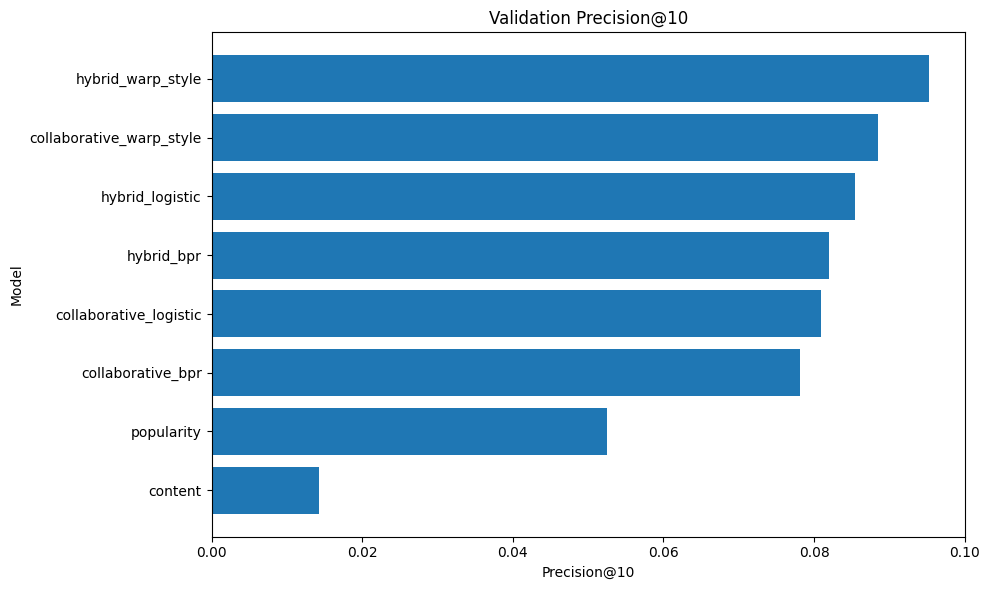

In [20]:
precision_plot = (
    default_validation_results[
        [
            "model",
            "precision_at_10",
        ]
    ]
    .sort_values(
        "precision_at_10"
    )
)

fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.barh(
    precision_plot["model"],
    precision_plot["precision_at_10"],
)

ax.set_title(
    "Validation Precision@10"
)
ax.set_xlabel(
    "Precision@10"
)
ax.set_ylabel(
    "Model"
)

plt.tight_layout()
plt.show()

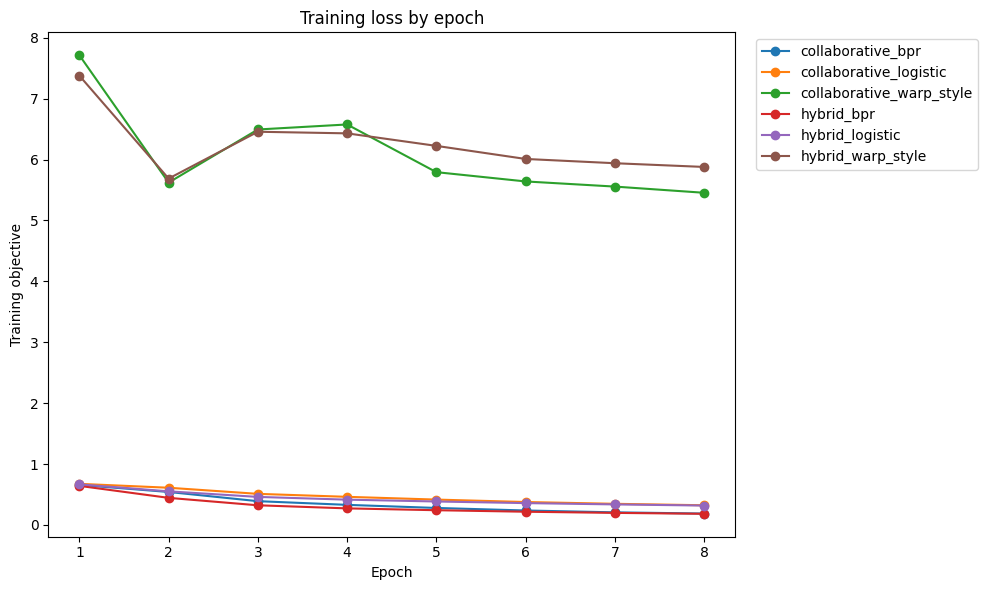

In [21]:
fig, ax = plt.subplots(
    figsize=(10, 6)
)

for model_name, model_history in (
    default_training_history.groupby(
        "model",
        sort=True,
    )
):
    ax.plot(
        model_history["epoch"],
        model_history["loss"],
        marker="o",
        label=model_name,
    )

ax.set_title(
    "Training loss by epoch"
)
ax.set_xlabel(
    "Epoch"
)
ax.set_ylabel(
    "Training objective"
)
ax.legend(
    bbox_to_anchor=(
        1.02,
        1,
    ),
    loc="upper left",
)

plt.tight_layout()
plt.show()

In [22]:
neural_results = (
    default_validation_results[
        default_validation_results[
            "model_family"
        ].eq("pytorch")
    ]
    .copy()
)

architecture_comparison = (
    neural_results
    .pivot(
        index="objective",
        columns="uses_metadata",
        values="precision_at_10",
    )
    .rename(
        columns={
            False: "collaborative",
            True: "hybrid",
        }
    )
)

architecture_comparison[
    "hybrid_lift"
] = (
    architecture_comparison[
        "hybrid"
    ]
    - architecture_comparison[
        "collaborative"
    ]
)

display(
    architecture_comparison
)

uses_metadata,collaborative,hybrid,hybrid_lift
objective,,,
bpr,0.078104,0.082043,0.003939
logistic,0.080975,0.085381,0.004406
warp_style_hard_negative,0.088451,0.095327,0.006876


In [23]:
selected_default_model = (
    default_run_summary[
        "selected_default_model"
    ]
)

print(
    "Selected default neural model:",
    selected_default_model,
)

print(
    "Test set accessed:",
    default_run_summary[
        "test_set_accessed"
    ],
)

display(
    default_examples[
        default_examples[
            "model"
        ].eq(
            selected_default_model
        )
    ][
        [
            "user_id",
            "rank",
            "title",
            "genre",
            "type",
            "validation_hit",
        ]
    ]
)

Selected default neural model: hybrid_warp_style
Test set accessed: False


,user_id,rank,title,genre,type,validation_hit
210,93,1,Hataraku Maou-sama!,"Comedy, Demons, Fantasy, Romance, Shounen",TV,True
211,93,2,Kami nomi zo Shiru Sekai,"Comedy, Harem, Romance, Shounen, Supernatural",TV,False
212,93,3,Haiyore! Nyaruko-san W,"Comedy, Parody, Sci-Fi",TV,False
213,93,4,High School DxD New,"Action, Comedy, Demons, Ecchi, Harem, Romance,...",TV,False
214,93,5,Haiyore! Nyaruko-san,"Comedy, Parody, Sci-Fi",TV,False
215,93,6,Nisekoi,"Comedy, Harem, Romance, School, Shounen",TV,False
216,93,7,D-Frag!,"Comedy, Game, School, Seinen",TV,False
217,93,8,High School DxD,"Comedy, Demons, Ecchi, Harem, Romance, School",TV,False
218,93,9,Mondaiji-tachi ga Isekai kara Kuru Sou Desu yo?,"Comedy, Fantasy, Supernatural",TV,False
219,93,10,Seitokai Yakuindomo*,"Comedy, School, Shounen, Slice of Life",TV,False


In [24]:
expected_default_models = {
    "popularity",
    "content",
    "collaborative_logistic",
    "collaborative_bpr",
    "collaborative_warp_style",
    "hybrid_logistic",
    "hybrid_bpr",
    "hybrid_warp_style",
}

assert set(
    default_validation_results[
        "model"
    ]
) == expected_default_models

assert (
    default_validation_results[
        [
            "precision_at_10",
            "recall_at_10",
            "ndcg_at_10",
            "hit_rate_at_10",
            "sampled_auc",
            "catalog_coverage_at_10",
            "intra_list_diversity_at_10",
        ]
    ]
    .apply(
        lambda column: column.between(
            0,
            1,
        ).all()
    )
    .all()
)

assert (
    default_run_summary[
        "cohort_split_sha256"
    ]
    == prepared.summary[
        "cohort_split_sha256"
    ]
)

assert (
    default_run_summary[
        "test_set_accessed"
    ]
    is False
)

print(
    "Default-model result checks passed."
)

Default-model result checks passed.


## 13. Selección del candidato por defecto

El candidato se selecciona únicamente entre los seis modelos neuronales utilizando Precision@10 de validación. NDCG@10 y Hit Rate@10 funcionan como criterios de desempate.

Esta selección todavía no representa el modelo final. El siguiente paso aplicará optimización bayesiana sobre la mejor familia de arquitectura y pérdida. El conjunto de prueba continúa completamente reservado.

## 14. Optimización bayesiana

La comparación por defecto seleccionó el modelo híbrido con pérdida WARP-style. La optimización mantiene fija esta arquitectura y explora sus hiperparámetros mediante Optuna y un muestreador TPE con semilla fija.

La función objetivo es Precision@10 sobre validación. NDCG@10 y Hit Rate@10 se utilizan únicamente como desempates determinísticos.

El trial 0 reproduce exactamente la configuración por defecto. Por lo tanto, el estudio contiene siempre el benchmark existente y la configuración seleccionada no puede ser inferior a este por la métrica principal.

### Espacio de búsqueda

Se optimizan la dimensión latente, cantidad de épocas, tamaño de lote, tasa de aprendizaje, regularización, peso de metadatos, cantidad máxima de negativos inspeccionados y margen de violación.

El conjunto de prueba permanece reservado. Todos los trials utilizan la misma cohorte, el mismo split y la misma semilla de entrenamiento.

In [25]:
OPTUNA_RESULTS_DIR = (
    ROOT
    / "results"
    / "optuna"
)

REQUIRED_OPTUNA_RESULT_FILES = [
    OPTUNA_RESULTS_DIR
    / "best_params.json",
    OPTUNA_RESULTS_DIR
    / "best_recommendations.npz",
    OPTUNA_RESULTS_DIR
    / "best_training_history.csv",
    OPTUNA_RESULTS_DIR
    / "best_validation_metrics.csv",
    OPTUNA_RESULTS_DIR
    / "parameter_importances.csv",
    OPTUNA_RESULTS_DIR
    / "recommendation_examples.csv",
    OPTUNA_RESULTS_DIR
    / "run_summary.json",
    OPTUNA_RESULTS_DIR
    / "trials.csv",
    OPTUNA_RESULTS_DIR
    / "validation_comparison.csv",
]

FORCE_RETUNE_SELECTED_MODEL = False

optuna_results_are_complete = all(
    path.exists()
    for path in REQUIRED_OPTUNA_RESULT_FILES
)

if (
    FORCE_RETUNE_SELECTED_MODEL
    or not optuna_results_are_complete
):
    conda_candidates = [
        os.environ.get("CONDA_EXE"),
        shutil.which("conda"),
        str(
            Path.home()
            / "miniconda3"
            / "Scripts"
            / "conda.exe"
        ),
        str(
            Path.home()
            / "anaconda3"
            / "Scripts"
            / "conda.exe"
        ),
    ]

    conda_executable = next(
        (
            candidate
            for candidate in conda_candidates
            if candidate
            and Path(candidate).exists()
        ),
        None,
    )

    if conda_executable is None:
        raise FileNotFoundError(
            "A Conda executable could not be located."
        )

    command = [
        conda_executable,
        "run",
        "-n",
        "apa-tp2-final",
        "--no-capture-output",
        "python",
        "scripts/tune_selected_model.py",
        "--overwrite",
    ]

    print(
        "Running:",
        " ".join(command),
        flush=True,
    )

    process = subprocess.Popen(
        command,
        cwd=ROOT,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        encoding="utf-8",
        errors="replace",
        bufsize=1,
    )

    assert process.stdout is not None

    for output_line in process.stdout:
        print(
            output_line,
            end="",
            flush=True,
        )

    return_code = process.wait()

    if return_code != 0:
        raise RuntimeError(
            "Optuna tuning failed with "
            f"exit code {return_code}."
        )
else:
    print(
        "Using existing validated Optuna results."
    )

Using existing validated Optuna results.


In [26]:
optuna_trials = pd.read_csv(
    OPTUNA_RESULTS_DIR
    / "trials.csv"
)

best_validation_metrics = pd.read_csv(
    OPTUNA_RESULTS_DIR
    / "best_validation_metrics.csv"
)

validation_comparison = pd.read_csv(
    OPTUNA_RESULTS_DIR
    / "validation_comparison.csv"
)

parameter_importances = pd.read_csv(
    OPTUNA_RESULTS_DIR
    / "parameter_importances.csv"
)

best_training_history = pd.read_csv(
    OPTUNA_RESULTS_DIR
    / "best_training_history.csv"
)

optuna_examples = pd.read_csv(
    OPTUNA_RESULTS_DIR
    / "recommendation_examples.csv"
)

with (
    OPTUNA_RESULTS_DIR
    / "best_params.json"
).open(
    "r",
    encoding="utf-8",
) as file:
    best_optuna_params = json.load(file)

with (
    OPTUNA_RESULTS_DIR
    / "run_summary.json"
).open(
    "r",
    encoding="utf-8",
) as file:
    optuna_run_summary = json.load(file)

display(
    validation_comparison
)

display(
    pd.DataFrame(
        {
            "parameter": list(
                best_optuna_params.keys()
            ),
            "value": list(
                best_optuna_params.values()
            ),
        }
    )
)

,model,variant,precision_at_10,recall_at_10,ndcg_at_10,hit_rate_at_10,catalog_coverage_at_10,intra_list_diversity_at_10,sampled_auc,precision_lift_vs_default
0,hybrid_warp_style,default,0.095327,0.169775,0.159897,0.616155,0.334290,0.574260,0.914764,0.000000
1,tuned_hybrid_warp_style,tuned,0.098264,0.180063,0.164174,0.634179,0.341263,0.590493,0.919925,0.002937


,parameter,value
0,source_model,hybrid_warp_style
1,objective,warp_style_hard_negative
2,use_metadata,True
3,latent_dim,64
4,epochs,10
5,batch_size,4096
6,learning_rate,0.00805
7,weight_decay,0.000002
8,metadata_weight,0.25
9,max_sampled,5


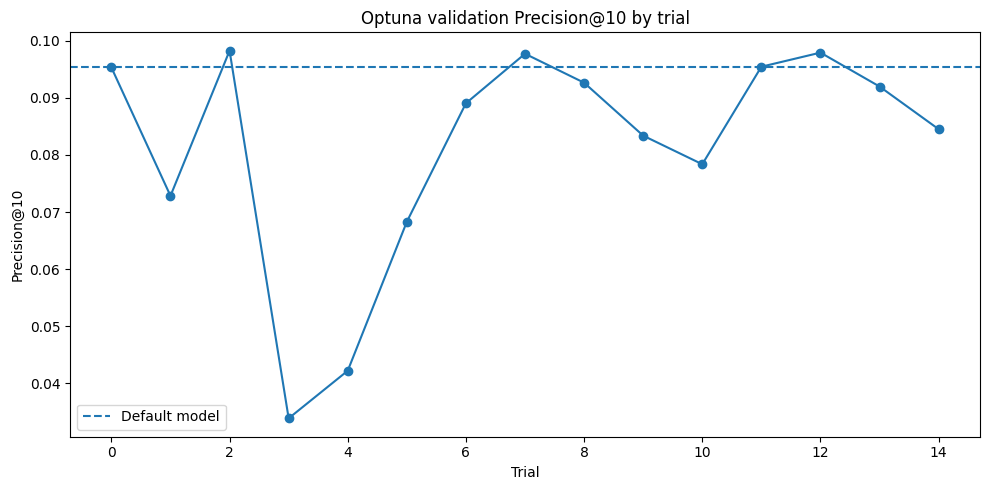

In [27]:
fig, ax = plt.subplots(
    figsize=(10, 5)
)

ax.plot(
    optuna_trials["trial_number"],
    optuna_trials["precision_at_10"],
    marker="o",
)

ax.axhline(
    validation_comparison.loc[
        validation_comparison[
            "variant"
        ].eq("default"),
        "precision_at_10",
    ].iloc[0],
    linestyle="--",
    label="Default model",
)

ax.set_title(
    "Optuna validation Precision@10 by trial"
)
ax.set_xlabel(
    "Trial"
)
ax.set_ylabel(
    "Precision@10"
)
ax.legend()

plt.tight_layout()
plt.show()

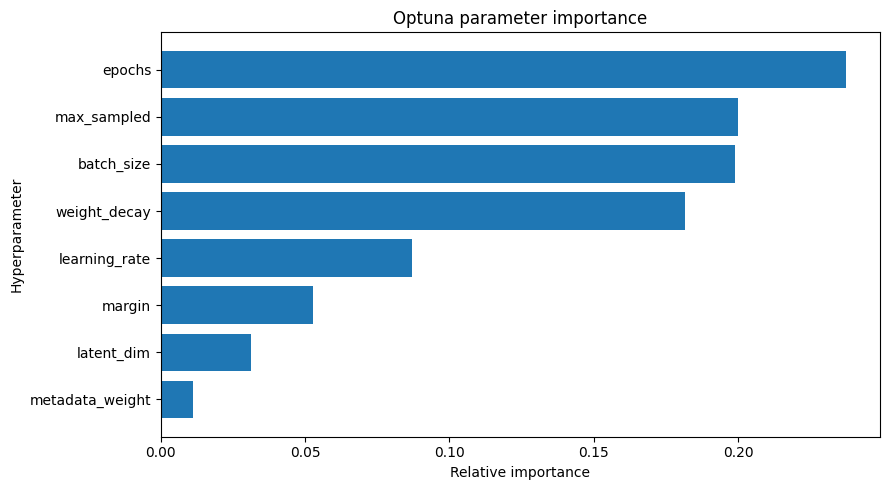

In [28]:
importance_plot = (
    parameter_importances
    .sort_values("importance")
)

fig, ax = plt.subplots(
    figsize=(9, 5)
)

ax.barh(
    importance_plot["parameter"],
    importance_plot["importance"],
)

ax.set_title(
    "Optuna parameter importance"
)
ax.set_xlabel(
    "Relative importance"
)
ax.set_ylabel(
    "Hyperparameter"
)

plt.tight_layout()
plt.show()

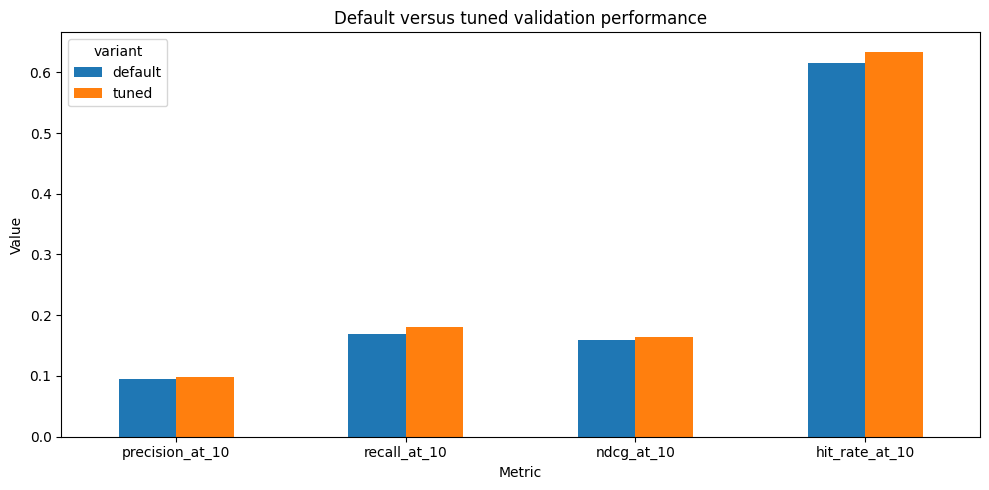

In [29]:
comparison_plot = (
    validation_comparison
    .set_index("variant")[
        [
            "precision_at_10",
            "recall_at_10",
            "ndcg_at_10",
            "hit_rate_at_10",
        ]
    ]
    .T
)

ax = comparison_plot.plot(
    kind="bar",
    figsize=(10, 5),
)

ax.set_title(
    "Default versus tuned validation performance"
)
ax.set_xlabel(
    "Metric"
)
ax.set_ylabel(
    "Value"
)
ax.tick_params(
    axis="x",
    rotation=0,
)

plt.tight_layout()
plt.show()

In [30]:
print(
    "Selected Optuna trial:",
    optuna_run_summary[
        "selected_trial_number"
    ],
)

print(
    "Precision lift versus default:",
    optuna_run_summary[
        "precision_lift_vs_default"
    ],
)

print(
    "Test set accessed:",
    optuna_run_summary[
        "test_set_accessed"
    ],
)

display(
    optuna_examples[
        [
            "user_id",
            "rank",
            "title",
            "genre",
            "type",
            "validation_hit",
        ]
    ]
)

Selected Optuna trial: 2
Precision lift versus default: 0.0029372496699599515
Test set accessed: False


,user_id,rank,title,genre,type,validation_hit
0,93,1,Chuunibyou demo Koi ga Shitai!,"Comedy, Drama, Romance, School, Slice of Life",TV,False
1,93,2,D-Frag!,"Comedy, Game, School, Seinen",TV,False
2,93,3,Hataraku Maou-sama!,"Comedy, Demons, Fantasy, Romance, Shounen",TV,True
3,93,4,High School DxD,"Comedy, Demons, Ecchi, Harem, Romance, School",TV,False
4,93,5,Yahari Ore no Seishun Love Comedy wa Machigatt...,"Comedy, Drama, Romance, School",TV,False
5,93,6,Mondaiji-tachi ga Isekai kara Kuru Sou Desu yo?,"Comedy, Fantasy, Supernatural",TV,False
6,93,7,Noragami,"Action, Adventure, Shounen, Supernatural",TV,False
7,93,8,"Ore no Nounai Sentakushi ga, Gakuen Love Comed...","Comedy, Romance, School",TV,False
8,93,9,Hentai Ouji to Warawanai Neko.,"Comedy, Harem, Romance, School, Seinen, Supern...",TV,False
9,93,10,Haiyore! Nyaruko-san W,"Comedy, Parody, Sci-Fi",TV,False


In [31]:
assert len(
    optuna_trials
) == config[
    "optuna_trials"
]

assert (
    optuna_trials[
        "state"
    ].eq("COMPLETE")
    .all()
)

assert (
    optuna_run_summary[
        "cohort_split_sha256"
    ]
    == prepared.summary[
        "cohort_split_sha256"
    ]
)

assert (
    optuna_run_summary[
        "test_set_accessed"
    ]
    is False
)

assert (
    validation_comparison.loc[
        validation_comparison[
            "variant"
        ].eq("tuned"),
        "precision_at_10",
    ].iloc[0]
    >=
    validation_comparison.loc[
        validation_comparison[
            "variant"
        ].eq("default"),
        "precision_at_10",
    ].iloc[0]
)

print(
    "Optuna result checks passed."
)

Optuna result checks passed.


## 15. Selección del modelo optimizado

El modelo ajustado se selecciona por Precision@10 de validación, con NDCG@10 y Hit Rate@10 como desempates. El trial seleccionado se vuelve a entrenar desde cero para confirmar que sus resultados son reproducibles.

A partir de este punto se congelan la arquitectura, la pérdida y los hiperparámetros. La siguiente fase combinará entrenamiento y validación, entrenará una única vez el modelo final y utilizará el conjunto de prueba por primera y única vez.